# Hierarchical Multi-Future GNN (Atom-Centric)

This notebook implements a two-level hierarchical graph structure to overcome the computational bottleneck of large molecular grids.

### The Problem:
- 10,000+ grid points create an over-smoothed, memory-intensive graph.
- Batching is difficult, and physical structure is lost in the "sea" of points.

### The Solution (Hierarchical GNN):
1. **Fine Level**: Grid points are grouped into patches centered around their nearest atoms.
2. **Pooling**: Local density information is aggregated into high-level atom embeddings.
3. **Coarse Level**: Message passing occurs *between atoms* (only 3-4 nodes), capturing global molecular physics efficiently.
4. **Decoding**: Updated atom states are broadcast back to grid points to predict future density snapshots ($t+5, t+10, t+15$).

- **Architecture**: Local GNN $\to$ Atom Pooling $\to$ Inter-Atom GAT $\to$ Global Forecast.

In [ ]:
!pip -q install numpy pandas matplotlib seaborn scikit-learn torch-geometric
import torch, os
print("Torch:", torch.__version__, "CUDA:", torch.cuda.is_available())

In [1]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATv2Conv, global_add_pool
from scipy.spatial.distance import cdist

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
# Robust Data Path Resolution
def resolve_raw_data_dir():
    candidates = [
        Path('../data/raw'),
        Path('./data/raw'),
        Path('/content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/data/raw'),
        Path('/home/varun/Desktop/someProj/GNNs/data/raw'),
    ]
    for p in candidates:
        if (p / 'ammonia_x').exists():
            return p.resolve()
    return Path('../data/raw') # Fallback

RAW_DATA_ROOT = resolve_raw_data_dir()
DATA_DIR = RAW_DATA_ROOT / 'ammonia_x'
print(f"Using data directory: {DATA_DIR}")

def parse_xyz(filepath):
    """Parses the rvlab.tdscf.xyz file for atom and grid coordinates."""
    atoms = []
    grid = []
    mode = None
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line == '[Atoms] (AU)': mode = 'atoms'; continue
            if line == '[Grid] (AU)': mode = 'grid'; continue
            
            parts = line.split()
            if not parts: continue
            
            if mode == 'atoms':
                # Element, ID, AtomicNum, X, Y, Z
                atoms.append([float(parts[3]), float(parts[4]), float(parts[5])])
            elif mode == 'grid':
                # ID, X, Y, Z
                grid.append([float(parts[1]), float(parts[2]), float(parts[3])])
                
    return np.array(atoms), np.array(grid)

xyz_file = DATA_DIR / 'rvlab.tdscf.xyz'
if xyz_file.exists():
    atom_coords, grid_coords = parse_xyz(xyz_file)
    print(f"Parsed geometry: {len(atom_coords)} atoms, {len(grid_coords)} grid points.")
else:
    print(f"XYZ file not found at {xyz_file}. Check paths.")

Using data directory: /home/varun/Desktop/someProj/GNNs/data/raw/ammonia_x
Parsed geometry: 4 atoms, 10540 grid points.


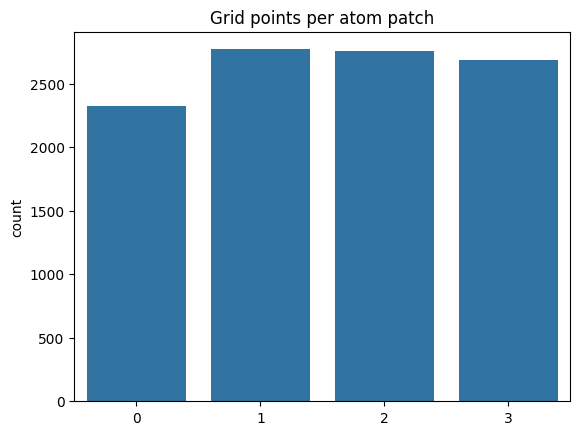

In [3]:
def assign_grid_to_atoms(atom_coords, grid_coords):
    """Assigns each grid point to its nearest atom (Voronoi partitioning)."""
    dists = cdist(grid_coords, atom_coords) # [N_grid, N_atoms]
    assignment = np.argmin(dists, axis=1)
    local_offsets = grid_coords - atom_coords[assignment] # [N_grid, 3]
    return assignment, local_offsets, dists.min(axis=1)

if xyz_file.exists():
    grid_assignment, grid_offsets, grid_dist_to_atom = assign_grid_to_atoms(atom_coords, grid_coords)
    sns.countplot(x=grid_assignment)
    plt.title("Grid points per atom patch")
    plt.show()

In [4]:
class HierarchicalDensityDataset(torch.utils.data.Dataset):
    def __init__(self, directory, future_offsets=[5, 10, 15]):
        self.dir = Path(directory)
        self.files = sorted(glob.glob(str(self.dir / 'rvlab.tdscf.rho.*')))
        self.offsets = future_offsets
        
        xyz_path = self.dir / 'rvlab.tdscf.xyz'
        if not xyz_path.exists():
             raise FileNotFoundError(f"Missing XYZ file at {xyz_path}")
             
        # Shared geometry
        self.atom_coords, self.grid_coords = parse_xyz(xyz_path)
        self.assignment, self.offsets_xyz, _ = assign_grid_to_atoms(self.atom_coords, self.grid_coords)
        
        # Convert assignment to torch
        self.assignment = torch.tensor(self.assignment, dtype=torch.long)
        self.offsets_xyz = torch.tensor(self.offsets_xyz, dtype=torch.float32)
        
        # Simple atom graph (fully connected since N is small)
        num_atoms = len(self.atom_coords)
        atom_edges = []
        for i in range(num_atoms):
            for j in range(num_atoms):
                if i != j: atom_edges.append([i, j])
        self.atom_edge_index = torch.tensor(atom_edges, dtype=torch.long).t().contiguous()

    def __len__(self):
        return len(self.files) - max(self.offsets)

    def __getitem__(self, idx):
        # Load current
        x_raw = np.loadtxt(self.files[idx], usecols=1)
        # Normalize locally
        mu, std = x_raw.mean(), x_raw.std() + 1e-6
        x_norm = (x_raw - mu) / std
        
        # Targets
        targets = []
        for off in self.offsets:
            t_raw = np.loadtxt(self.files[idx + off], usecols=1)
            targets.append((t_raw - mu) / std)
        
        return {
            'grid_x': torch.tensor(x_norm, dtype=torch.float32).unsqueeze(-1), # [N_grid, 1]
            'grid_pos': self.offsets_xyz, # Relative coords [N_grid, 3]
            'assignment': self.assignment, # Map from grid to atom ID
            'atom_edge_index': self.atom_edge_index,
            'y': torch.tensor(np.column_stack(targets), dtype=torch.float32), # [N_grid, 3]
            'stats': (mu, std)
        }

# Use the resolved DATA_DIR
dataset = HierarchicalDensityDataset(DATA_DIR)
print(f"Dataset initialized with {len(dataset)} trajectory pairs.")

Dataset initialized with 386 trajectory pairs.


In [5]:
class HierarchicalGNN(nn.Module):
    """
    A Multi-level GNN: Grid -> Atom Pooling -> Atom Interaction -> Grid Decoding.
    This is physically more sound and computationally efficient. :)
    """
    def __init__(self, hidden_dim=64, num_futures=3):
        super().__init__()
        
        # 1. Local Grid Encoder
        # Input: density + rel_x, rel_y, rel_z (dim=4)
        self.grid_encoder = nn.Sequential(
            nn.Linear(4, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )
        
        # 2. Inter-Atom Messenger
        self.atom_gnn = GATv2Conv(hidden_dim, hidden_dim // 2, heads=2, edge_dim=None)
        self.atom_norm = nn.LayerNorm(hidden_dim)
        
        # 3. Trajectory Decoder (Predicts back at grid level)
        # Input: Up-sampled atom features + local grid context
        self.decoder = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim + 4, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1)
            ) for _ in range(num_futures)
        ])

    def forward(self, batch_data):
        grid_x = batch_data['grid_x'].to(device)     # [B*10540, 1]
        grid_pos = batch_data['grid_pos'].to(device) # [B*10540, 3]
        assignment = batch_data['assignment'].to(device) # [B*10540]
        atom_edges = batch_data['atom_edge_index'].to(device)
        
        # --- Phase 1: Patch Encoding ---
        grid_features = torch.cat([grid_x, grid_pos], dim=-1)
        h_grid = self.grid_encoder(grid_features) # [N_grid, hidden]
        
        # --- Phase 2: Atom Pooling ---
        # Aggregate grid points into atom settlements
        h_atoms = global_add_pool(h_grid, assignment)
        
        # --- Phase 3: Global Message Passing ---
        # Simple GAT between atoms
        h_atoms = self.atom_gnn(h_atoms, atom_edges)
        h_atoms = self.atom_norm(h_atoms)
        
        # --- Phase 4: Decoding ---
        # Broadcast atom features back to their grid point children
        h_atom_broadcast = h_atoms[assignment]
        
        # Combine global context with local grid details
        final_context = torch.cat([h_atom_broadcast, grid_features], dim=-1)
        
        preds = [head(final_context).squeeze(-1) for head in self.decoder]
        return torch.stack(preds, dim=-1)

model = HierarchicalGNN().to(device)
print("Hierarchical model ready to bridge the scale gap! :)")

Hierarchical model ready to bridge the scale gap! :)


In [6]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=1, shuffle=True) # Now we can handle batching better manually if needed
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

model.train()
print("Starting Hierarchical Training...")
for epoch in range(5):
    total_loss = 0
    for i, batch in enumerate(loader):
        optimizer.zero_grad()
        
        # Squeeze batch dimension for GNN processing
        batch_flat = {k: v.squeeze(0) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        
        pred = model(batch_flat)
        target = batch_flat['y'].to(device)
        
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        if i % 20 == 0: print(f"Step {i} | Loss: {loss.item():.6f}")
        
    print(f"Epoch {epoch+1} Complete | Avg Loss: {total_loss/len(loader):.6f}")

Starting Hierarchical Training...
Step 0 | Loss: 1.080812
Step 20 | Loss: 0.738678
Step 40 | Loss: 0.544201
Step 60 | Loss: 0.348945
Step 80 | Loss: 0.175225
Step 100 | Loss: 0.060407
Step 120 | Loss: 0.011559
Step 140 | Loss: 0.001095
Step 160 | Loss: 0.000250
Step 180 | Loss: 0.000144
Step 200 | Loss: 0.000433
Step 220 | Loss: 0.000110
Step 240 | Loss: 0.000088
Step 260 | Loss: 0.000072
Step 280 | Loss: 0.001321
Step 300 | Loss: 0.000180
Step 320 | Loss: 0.000063
Step 340 | Loss: 0.000041
Step 360 | Loss: 0.000080
Step 380 | Loss: 0.001005
Epoch 1 Complete | Avg Loss: 0.123171
Step 0 | Loss: 0.000352
Step 20 | Loss: 0.000042
Step 40 | Loss: 0.000028
Step 60 | Loss: 0.000024
Step 80 | Loss: 0.000029
Step 100 | Loss: 0.000417
Step 120 | Loss: 0.000084
Step 140 | Loss: 0.000017
Step 160 | Loss: 0.000110
Step 180 | Loss: 0.000065
Step 200 | Loss: 0.000016
Step 220 | Loss: 0.000018
Step 240 | Loss: 0.000027
Step 260 | Loss: 0.000188
Step 280 | Loss: 0.000053
Step 300 | Loss: 0.000014
Step

### Conclusion:
By using **Atoms** as the primary message-passing nodes, we reduced the complexity of global information exchange from $O(N_{grid}^2)$ to $O(N_{atoms}^2)$ or $O(N_{atoms} \times N_{grid})$. 

This abstraction is not only faster but aligns with the **Chemical Intuition** that electron density is strongly tied to atomic nuclei positions and their mutual interactions (bonds). :)